# Telco Customer Churn Prediction

## Project Overview
This notebook builds a machine learning model to predict customer churn
for a telecommunications company. We use a real-world dataset of 7,043
customers with 21 features including demographics, services, and account info.

## Goals
- Understand what drives customer churn through exploratory analysis
- Build and compare multiple prediction models
- Identify the most important features for retention decisions

**Dataset:** [IBM Telco Customer Churn (via Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)    
**Author:** Adam Faik

In [1]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [2]:
# --- Imports ---
# We load all our tools at the top so they're available throughout the notebook

import pandas as pd           # pandas handles our data - we nickname it 'pd' to type less
import matplotlib.pyplot as plt  # matplotlib draws charts - 'plt' is the universal nickname
import seaborn as sns          # seaborn makes prettier charts with less code

# This line tells matplotlib to display charts directly inside the notebook
%matplotlib inline

# Print a confirmation so we know everything loaded without errors
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# --- Load the Dataset ---

# pd.read_csv() reads a CSV file and turns it into a DataFrame
# We store it in a variable called 'df' - short for DataFrame
# 'df' is the universal nickname every data scientist uses
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# This prints a confirmation showing how many rows and columns we loaded
# df.shape returns two numbers: (rows, columns)
print(f"Dataset loaded! Shape: {df.shape}")
print(f"That's {df.shape[0]} customers and {df.shape[1]} features.")

Dataset loaded! Shape: (7043, 21)
That's 7043 customers and 21 features.


In [4]:
# --- First Look at the Data ---

# .head() shows the first 5 rows of the DataFrame
# Like peeking at the top of a spreadsheet
print("=== First 5 rows ===")
df.head()

=== First 5 rows ===


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# .info() gives us a summary of every column:
# - how many non-null (non-missing) values it has
# - what data type it is (int, float, object=text)
print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null 

In [6]:
# --- Statistical Summary ---

# .describe() automatically calculates key statistics for every numerical column
# count = how many values, mean = average, std = spread,
# min/max = extremes, 25%/50%/75% = distribution markers
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# --- Fix TotalCharges Data Type ---

# First, let's see the problem up close
# We find rows where TotalCharges is just a blank space ' '
# strip() removes whitespace, so '  ' becomes '' (empty string)
problem_rows = df[df['TotalCharges'].str.strip() == '']
print(f"Rows with blank TotalCharges: {len(problem_rows)}")

# Let's see those problem rows
print(problem_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

Rows with blank TotalCharges: 11
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


In [8]:
# --- Clean TotalCharges ---

# Step 1: Remove the 11 rows where TotalCharges is blank
# We keep only rows where TotalCharges is NOT an empty string after stripping whitespace
df = df[df['TotalCharges'].str.strip() != '']

# Step 2: Convert TotalCharges from text to a decimal number (float)
# pd.to_numeric() does the conversion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

# Step 3: Confirm the fix worked
print(f"Rows remaining: {len(df)}")         # Should be 7032 (7043 minus 11)
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")  # Should say float64 now

Rows remaining: 7032
TotalCharges dtype: float64


In [9]:
# --- Drop customerID ---

# .drop() removes a column from the DataFrame
# axis=1 means "drop a column" (axis=0 would mean "drop a row")
# inplace=True means "modify df directly, don't create a copy"
df.drop('customerID', axis=1, inplace=True)

# Confirm it's gone - should now show 20 columns instead of 21
print(f"Columns remaining: {df.shape[1]}")
print(f"Column names: {list(df.columns)}")

Columns remaining: 20
Column names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [10]:
# --- Convert Churn to Binary (0/1) ---

# .map() replaces every value in a column using a dictionary
# 'No' gets replaced with 0, 'Yes' gets replaced with 1
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Confirm the conversion worked
print(f"Churn value counts:")
print(df['Churn'].value_counts())
print(f"\nChurn rate: {df['Churn'].mean():.1%}")  # .mean() on 0/1 gives us the % of 1s

Churn value counts:
Churn
0    5163
1    1869
Name: count, dtype: int64

Churn rate: 26.6%


In [11]:
# --- Final Data Quality Check ---

# .isnull().sum() counts missing values in every column
# A column with 0 means no missing values - exactly what we want
print("=== Missing values per column ===")
print(df.isnull().sum())

# Confirm final shape
print(f"\n=== Final dataset shape ===")
print(f"{df.shape[0]} rows, {df.shape[1]} columns")

# Quick peek at the cleaned data
print(f"\n=== First 3 rows of clean data ===")
df.head(3)

=== Missing values per column ===
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== Final dataset shape ===
7032 rows, 20 columns

=== First 3 rows of clean data ===


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


/var/folders/kv/g0g8nw2j0jbbsk8g5j6dxdbr0000gp/T/ipykernel_16711/2932770025.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette=['steelblue', 'salmon'], ax=ax)
/var/folders/kv/g0g8nw2j0jbbsk8g5j6dxdbr0000gp/T/ipykernel_16711/2932770025.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Stayed (73.4%)', 'Churned (26.6%)'])


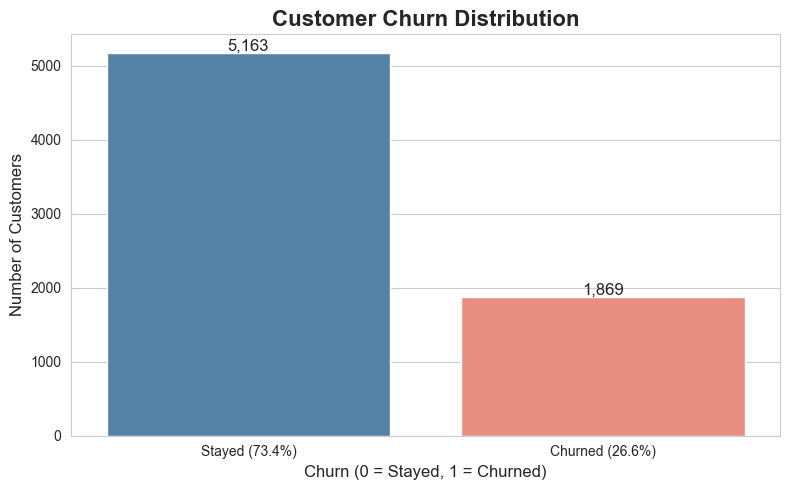

In [12]:
# --- Chart 1: Overall Churn Rate ---

# Set the visual style for all our charts - 'whitegrid' adds subtle grid lines
sns.set_style("whitegrid")

# Create a figure - think of this as setting up a blank canvas
# figsize=(8,5) sets the width and height in inches
fig, ax = plt.subplots(figsize=(8, 5))

# countplot counts how many 0s and 1s are in Churn and draws bars
# palette sets the colors: blue for stayed, orange for churned
sns.countplot(data=df, x='Churn', palette=['steelblue', 'salmon'], ax=ax)

# Label the bars with actual numbers so we don't have to eyeball the chart
for p in ax.patches:                          # loop through each bar
    ax.annotate(f'{int(p.get_height()):,}',   # format the number with comma
                (p.get_x() + p.get_width()/2, p.get_height()),  # position above bar
                ha='center', va='bottom', fontsize=12)           # center it

# Add titles and labels
ax.set_title('Customer Churn Distribution', fontsize=16, fontweight='bold')
ax.set_xlabel('Churn (0 = Stayed, 1 = Churned)', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_xticklabels(['Stayed (73.4%)', 'Churned (26.6%)'])

plt.tight_layout()  # prevents labels from getting cut off
plt.show()          # displays the chart

/var/folders/kv/g0g8nw2j0jbbsk8g5j6dxdbr0000gp/T/ipykernel_16711/1958902605.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='ChurnRate',


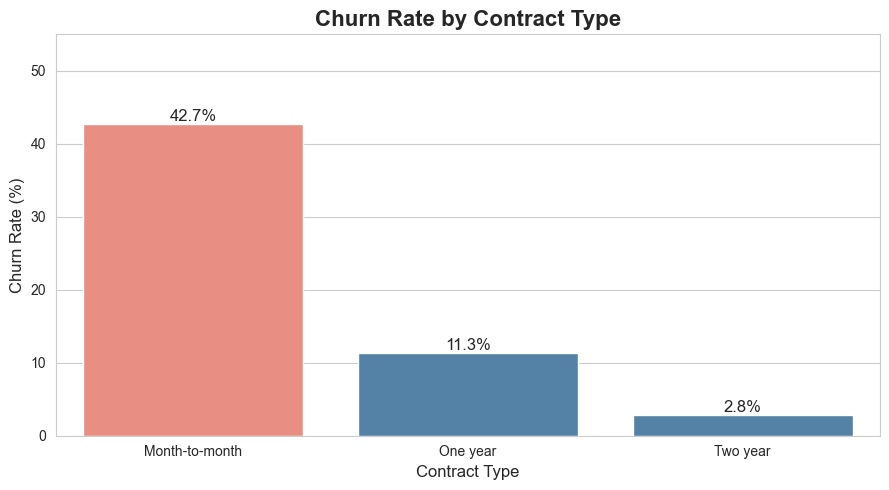

In [13]:
# --- Chart 2: Churn by Contract Type ---

fig, ax = plt.subplots(figsize=(9, 5))

# Instead of raw counts, we want percentages of churners per contract type
# We group by Contract, calculate mean of Churn (remember: mean of 0/1 = churn rate)
# multiply by 100 to get percentages, then reset_index to make it a clean DataFrame
contract_churn = df.groupby('Contract')['Churn'].mean().mul(100).reset_index()
contract_churn.columns = ['Contract', 'ChurnRate']  # rename columns for clarity

# Sort by churn rate so the chart reads cleanly
contract_churn = contract_churn.sort_values('ChurnRate', ascending=False)

# Draw the bar chart
sns.barplot(data=contract_churn, x='Contract', y='ChurnRate', 
            palette=['salmon', 'steelblue', 'steelblue'], ax=ax)

# Add percentage labels on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

ax.set_title('Churn Rate by Contract Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Contract Type', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 55)  # give space above bars for labels

plt.tight_layout()
plt.show()

/var/folders/kv/g0g8nw2j0jbbsk8g5j6dxdbr0000gp/T/ipykernel_16711/1310795180.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tenure_churn, x='Tenure (Months)', y='ChurnRate',


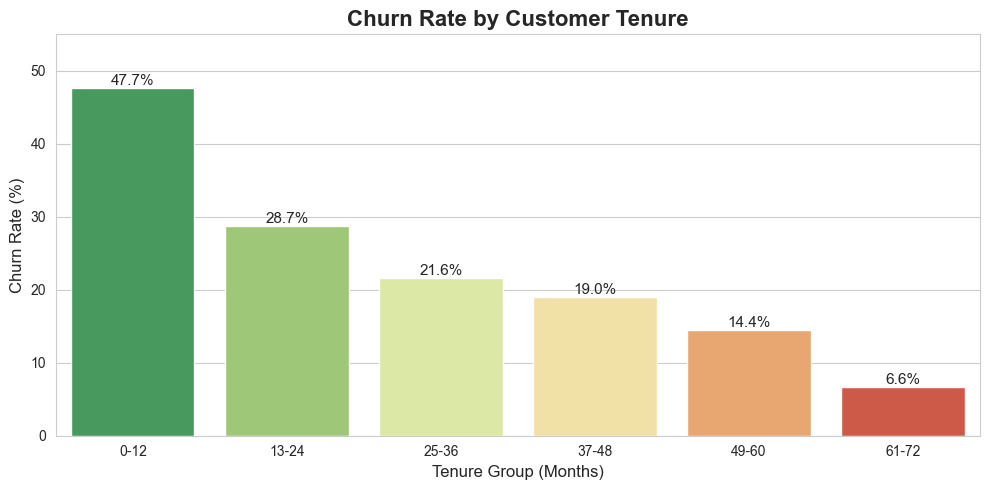

In [14]:
# --- Chart 3: Churn by Tenure ---

fig, ax = plt.subplots(figsize=(10, 5))

# Instead of individual months, we'll group tenure into buckets
# pd.cut() divides a continuous number into labeled categories
df['tenure_group'] = pd.cut(df['tenure'], 
                             bins=[0, 12, 24, 36, 48, 60, 72],
                             labels=['0-12', '13-24', '25-36', 
                                     '37-48', '49-60', '61-72'])

# Calculate churn rate per tenure group
tenure_churn = df.groupby('tenure_group', observed=True)['Churn'].mean().mul(100).reset_index()
tenure_churn.columns = ['Tenure (Months)', 'ChurnRate']

# Draw the bar chart
sns.barplot(data=tenure_churn, x='Tenure (Months)', y='ChurnRate',
            palette='RdYlGn_r', ax=ax)  # red=high churn, green=low churn

# Add percentage labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)

ax.set_title('Churn Rate by Customer Tenure', fontsize=16, fontweight='bold')
ax.set_xlabel('Tenure Group (Months)', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 55)

plt.tight_layout()
plt.show()

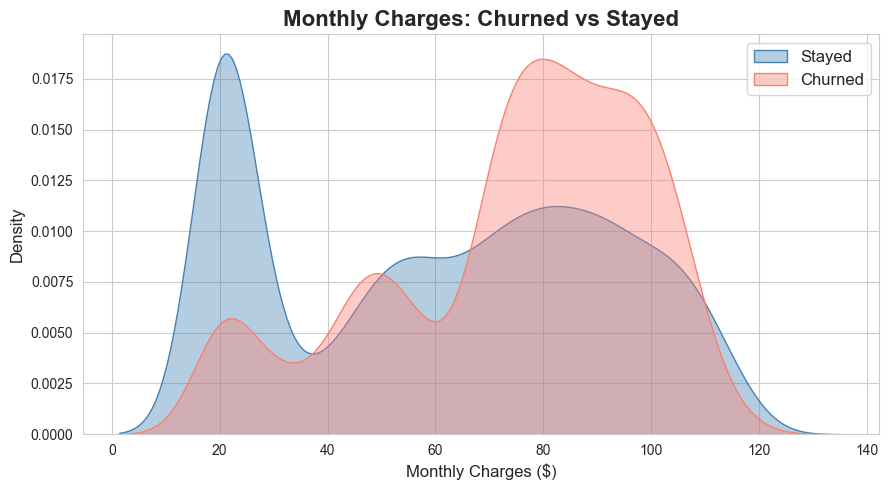

In [15]:
# --- Chart 4: Monthly Charges Distribution by Churn ---

fig, ax = plt.subplots(figsize=(9, 5))

# A KDE plot (Kernel Density Estimate) shows the distribution shape
# Think of it as a smoothed histogram
# We draw one curve for churners and one for non-churners
sns.kdeplot(data=df[df['Churn']==0]['MonthlyCharges'],  # customers who stayed
            label='Stayed', color='steelblue', 
            fill=True, alpha=0.4, ax=ax)   # alpha controls transparency

sns.kdeplot(data=df[df['Churn']==1]['MonthlyCharges'],  # customers who churned
            label='Churned', color='salmon',
            fill=True, alpha=0.4, ax=ax)

ax.set_title('Monthly Charges: Churned vs Stayed', fontsize=16, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

/var/folders/kv/g0g8nw2j0jbbsk8g5j6dxdbr0000gp/T/ipykernel_16711/1766834613.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=internet_churn, x='InternetService', y='ChurnRate',


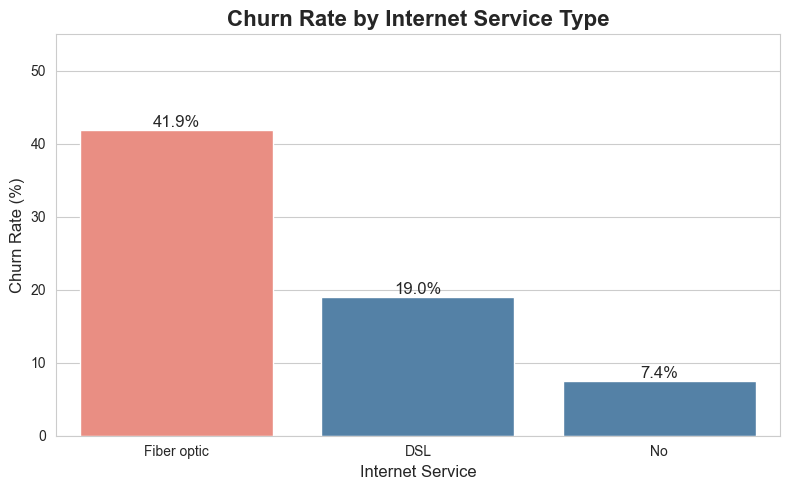

In [16]:
# --- Chart 5: Churn Rate by Internet Service ---

fig, ax = plt.subplots(figsize=(8, 5))

internet_churn = df.groupby('InternetService')['Churn'].mean().mul(100).reset_index()
internet_churn.columns = ['InternetService', 'ChurnRate']
internet_churn = internet_churn.sort_values('ChurnRate', ascending=False)

sns.barplot(data=internet_churn, x='InternetService', y='ChurnRate',
            palette=['salmon', 'steelblue', 'steelblue'], ax=ax)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

ax.set_title('Churn Rate by Internet Service Type', fontsize=16, fontweight='bold')
ax.set_xlabel('Internet Service', fontsize=12)
ax.set_ylabel('Churn Rate (%)', fontsize=12)
ax.set_ylim(0, 55)

plt.tight_layout()
plt.show()

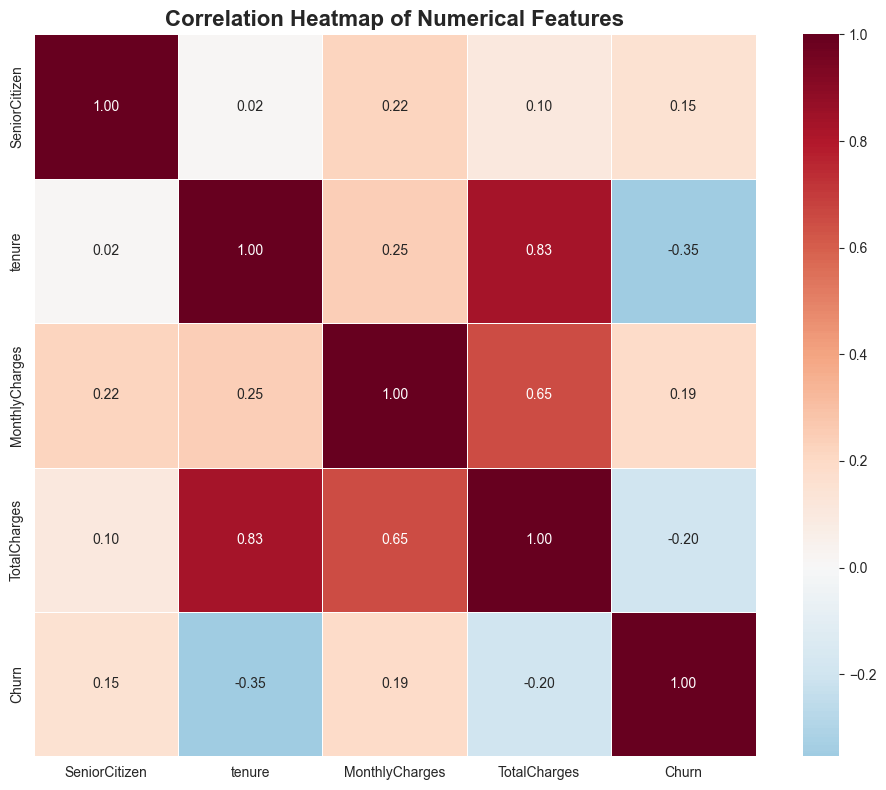

In [17]:
# --- Chart 6: Correlation Heatmap ---

fig, ax = plt.subplots(figsize=(10, 8))

# .corr() calculates the correlation between every pair of numerical columns
# Correlation ranges from -1 (opposite) to +1 (identical) to 0 (no relationship)
correlation_matrix = df[['SeniorCitizen', 'tenure', 
                          'MonthlyCharges', 'TotalCharges', 'Churn']].corr()

# sns.heatmap draws the correlation matrix as a colour-coded grid
# annot=True prints the actual numbers inside each square
# cmap sets the colour scheme: red=positive, blue=negative correlation
# fmt='.2f' formats numbers to 2 decimal places
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdBu_r',
            fmt='.2f',
            center=0,                    # white = zero correlation
            square=True,                 # keep cells square shaped
            linewidths=0.5,              # thin lines between cells
            ax=ax)

ax.set_title('Correlation Heatmap of Numerical Features', 
             fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
# --- Separate Features and Target ---

# X contains every column EXCEPT Churn - these are our inputs
# drop() here removes Churn temporarily, leaving us with 19 feature columns
# axis=1 means we're dropping a column (not a row)
X = df.drop('Churn', axis=1)

# y contains ONLY the Churn column - this is what we're predicting
y = df['Churn']

# Also drop the tenure_group column we created for charting in Phase 4
# It's a derived column, not an original feature, so we don't want it as an input
X = X.drop('tenure_group', axis=1)

# Confirm the shapes make sense
print(f"Features (X): {X.shape}")   # Should be (7032, 19)
print(f"Target (y): {y.shape}")     # Should be (7032,)
print(f"\nFeature columns:\n{list(X.columns)}")

Features (X): (7032, 19)
Target (y): (7032,)

Feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [19]:
# --- Train/Test Split ---

# Import the splitting tool from scikit-learn
from sklearn.model_selection import train_test_split

# Split both X and y simultaneously - scikit-learn keeps them aligned
# test_size=0.2 means 20% goes to test, 80% goes to training
# random_state=42 is a "seed" - it means the split is random but reproducible
# Every time you run this you'll get the exact same split, which is important
# for comparing models fairly later
# stratify=y ensures both splits have the same 26.6% churn rate
# without this, by bad luck one split might have very few churners
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y        
)

# Confirm the sizes
print(f"Training set: {X_train.shape[0]} customers")
print(f"Test set: {X_test.shape[0]} customers")
print(f"\nChurn rate in training set: {y_train.mean():.1%}")
print(f"Churn rate in test set: {y_test.mean():.1%}")

Training set: 5625 customers
Test set: 1407 customers

Churn rate in training set: 26.6%
Churn rate in test set: 26.6%


In [20]:
# --- One-Hot Encoding ---

# Get_dummies() automatically finds all text columns and one-hot encodes them
# drop_first=True drops the first category of each column to avoid redundancy
# (if DSL=0 and Fiber=0, we already know it must be No - no need for a third column)
# This is called the "dummy variable trap" - drop_first=True avoids it
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Confirm the new shape - we'll have more columns now
print(f"Columns before encoding: 19")
print(f"Columns after encoding: {X_train_encoded.shape[1]}")
print(f"\nNew column names:")
print(list(X_train_encoded.columns))

Columns before encoding: 19
Columns after encoding: 30

New column names:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [21]:
# --- Feature Scaling ---

from sklearn.preprocessing import StandardScaler

# Identify the numerical columns that need scaling
# The encoded binary columns (0/1) are already on the same scale - leave them alone
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Create the scaler object
scaler = StandardScaler()

# IMPORTANT: We fit the scaler ONLY on training data
# fit_transform() learns the mean and std from training data, then scales it
# This is where your data leakage instinct from Phase 3 pays off --
# if we fit on all data, test set info would leak into training
X_train_encoded[numerical_cols] = scaler.fit_transform(
    X_train_encoded[numerical_cols]
)

# transform() ONLY - we apply the training scale to test data
# We never fit on test data - the scaler already knows what it needs to know
X_test_encoded[numerical_cols] = scaler.transform(
    X_test_encoded[numerical_cols]
)

# Confirm by checking the mean and std of scaled training columns
print("After scaling (training set):")
print(X_train_encoded[numerical_cols].describe().round(2))

After scaling (training set):
        tenure  MonthlyCharges  TotalCharges
count  5625.00         5625.00       5625.00
mean     -0.00            0.00          0.00
std       1.00            1.00          1.00
min      -1.29           -1.55         -1.00
25%      -0.96           -0.97         -0.83
50%      -0.15            0.19         -0.39
75%       0.96            0.83          0.66
max       1.61            1.78          2.81


In [22]:
# --- Final Verification ---

print("=== Training Set ===")
print(f"X_train shape: {X_train_encoded.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Churn rate: {y_train.mean():.1%}")

print("\n=== Test Set ===")
print(f"X_test shape: {X_test_encoded.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Churn rate: {y_test.mean():.1%}")

print("\n=== Ready for modelling! ===")
print(f"Each customer is represented by {X_train_encoded.shape[1]} features")
print(f"All features are numerical: {all(X_train_encoded.dtypes != 'object')}")

=== Training Set ===
X_train shape: (5625, 30)
y_train shape: (5625,)
Churn rate: 26.6%

=== Test Set ===
X_test shape: (1407, 30)
y_test shape: (1407,)
Churn rate: 26.6%

=== Ready for modelling! ===
Each customer is represented by 30 features
All features are numerical: True


In [23]:
# --- Evaluation Setup ---

from sklearn.metrics import (
    accuracy_score,      # overall % correct
    precision_score,     # of predicted churners, how many were right
    recall_score,        # of actual churners, how many did we catch
    f1_score,            # balance of precision and recall
    roc_auc_score,       # overall discrimination ability
    confusion_matrix,    # 2x2 grid of correct/incorrect predictions
    classification_report # neat summary of all metrics at once
)

# We'll store all model results here to compare at the end
results = {}

# A helper function that evaluates any model and stores its scores
# This saves us rewriting the same code three times
def evaluate_model(name, y_test, y_pred, y_prob):
    scores = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_prob)
    }
    results[name] = scores  # store in our results dictionary
    
    print(f"\n=== {name} ===")
    for metric, value in scores.items():
        print(f"{metric}: {value:.3f}")  # print each score to 3 decimal places
    return scores

print("Evaluation tools ready!")

Evaluation tools ready!


In [24]:
# --- Model 1: Logistic Regression ---

from sklearn.linear_model import LogisticRegression

# Create the model object
# max_iter=1000 gives it enough iterations to find the best solution
# random_state=42 makes results reproducible
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# .fit() is where the actual learning happens
# We show it the training features AND the correct answers
# It finds the best line that separates churners from stayers
lr_model.fit(X_train_encoded, y_train)

# .predict() uses the learned line to classify each test customer
# Returns 0 or 1 for each customer
y_pred_lr = lr_model.predict(X_test_encoded)

# .predict_proba() returns the probability of churn (0.0 to 1.0)
# [:,1] takes the probability of class 1 (churned)
# This is used for ROC-AUC which needs probabilities not just 0/1
y_prob_lr = lr_model.predict_proba(X_test_encoded)[:,1]

# Evaluate using our helper function
evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)

# Print the full classification report for extra detail
print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed', 'Churned']))


=== Logistic Regression ===
Accuracy: 0.805
Precision: 0.650
Recall: 0.572
F1 Score: 0.609
ROC-AUC: 0.836

Full Classification Report:
              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [25]:
# --- Model 2: Random Forest ---

from sklearn.ensemble import RandomForestClassifier

# n_estimators=500 means we build 500 decision trees
# random_state=42 keeps results reproducible
rf_model = RandomForestClassifier(n_estimators=500, random_state=42)

# Same pattern as before: fit on training data
print("Training Random Forest (this may take a few seconds)...")
rf_model.fit(X_train_encoded, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test_encoded)
y_prob_rf = rf_model.predict_proba(X_test_encoded)[:,1]

# Evaluate
evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Stayed', 'Churned']))

Training Random Forest (this may take a few seconds)...

=== Random Forest ===
Accuracy: 0.790
Precision: 0.628
Recall: 0.511
F1 Score: 0.563
ROC-AUC: 0.820

Full Classification Report:
              precision    recall  f1-score   support

      Stayed       0.83      0.89      0.86      1033
     Churned       0.63      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [26]:
# --- Model 3: XGBoost ---

from xgboost import XGBClassifier

# scale_pos_weight handles our class imbalance (73% stayed vs 26% churned)
# We tell XGBoost to weight churners more heavily so it doesn't ignore them
# The ratio is: number of non-churners / number of churners
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=500,           # number of trees to build sequentially
    learning_rate=0.05,         # how much each tree corrects the previous ones
    max_depth=6,                # how deep each tree can grow
    scale_pos_weight=scale_pos_weight,  # handle class imbalance
    random_state=42,
    eval_metric='logloss',      # how it measures its own error internally
    verbosity=0                 # suppress training output messages
)

print("Training XGBoost (this may take a few seconds)...")
xgb_model.fit(X_train_encoded, y_train)

y_pred_xgb = xgb_model.predict(X_test_encoded)
y_prob_xgb = xgb_model.predict_proba(X_test_encoded)[:,1]

evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Stayed', 'Churned']))

Training XGBoost (this may take a few seconds)...

=== XGBoost ===
Accuracy: 0.749
Precision: 0.520
Recall: 0.714
F1 Score: 0.602
ROC-AUC: 0.821

Full Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.76      0.82      1033
     Churned       0.52      0.71      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.78      0.75      0.76      1407



=== Model Comparison ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     0.805      0.650   0.572     0.609    0.836
Random Forest           0.790      0.628   0.511     0.563    0.820
XGBoost                 0.749      0.520   0.714     0.602    0.821


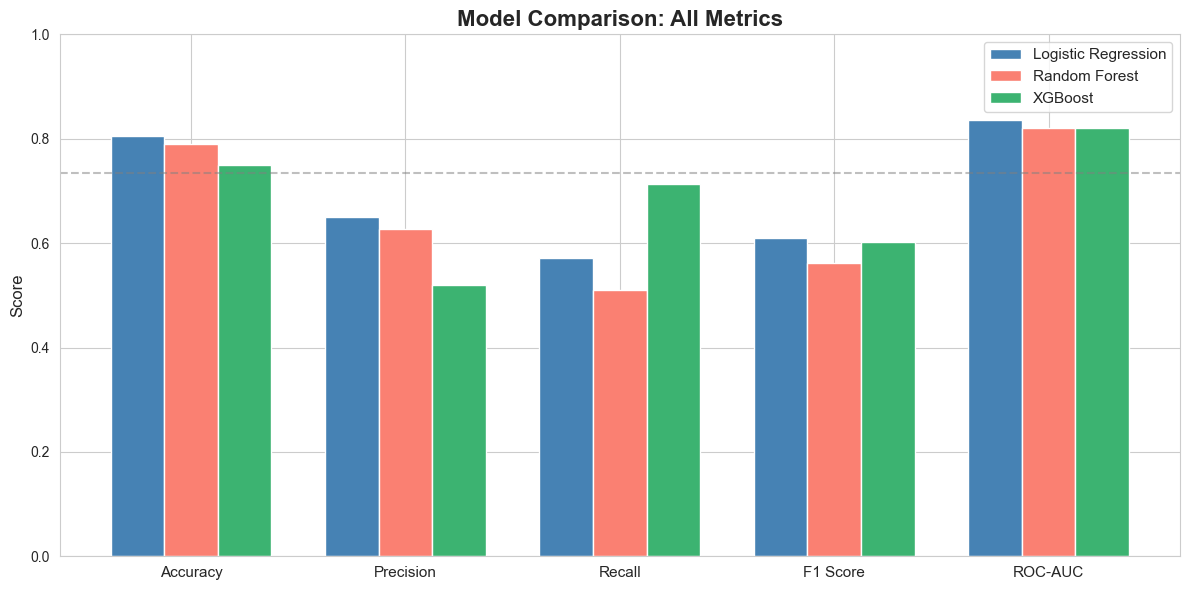

In [27]:
# --- Model Comparison Chart ---

import pandas as pd

# Build a clean comparison DataFrame from our results dictionary
results_df = pd.DataFrame(results).T  # .T transposes rows and columns
results_df = results_df.round(3)

print("=== Model Comparison ===")
print(results_df)

# Plot all metrics side by side for each model
fig, ax = plt.subplots(figsize=(12, 6))

# Plot grouped bars - one group per metric, one bar per model
x = range(len(results_df.columns))  # positions for each metric on x axis
width = 0.25                         # width of each bar

# Draw one set of bars per model
bars1 = ax.bar([i - width for i in x], results_df.loc['Logistic Regression'],
               width, label='Logistic Regression', color='steelblue')
bars2 = ax.bar([i for i in x], results_df.loc['Random Forest'],
               width, label='Random Forest', color='salmon')
bars3 = ax.bar([i + width for i in x], results_df.loc['XGBoost'],
               width, label='XGBoost', color='mediumseagreen')

ax.set_title('Model Comparison: All Metrics', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df.columns, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.axhline(y=0.734, color='gray', linestyle='--', 
           alpha=0.5, label='Naive baseline (73.4%)')

plt.tight_layout()
plt.show()

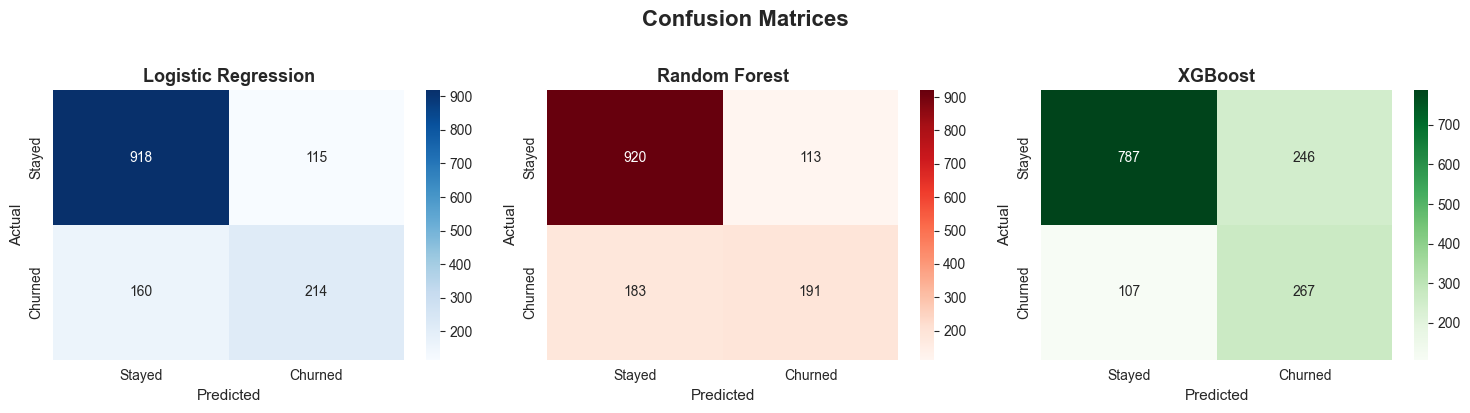

In [28]:
# --- Confusion Matrices for All Three Models ---

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  # 1 row, 3 side-by-side charts

# Store our predictions in a neat dictionary to loop through
models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

colors = ['Blues', 'Reds', 'Greens']  # different colormap per model

for ax, (name, y_pred), color in zip(axes, models.items(), colors):
    
    # Calculate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Draw it as a heatmap
    sns.heatmap(cm, 
                annot=True,          # show numbers inside cells
                fmt='d',             # format as integers not decimals
                cmap=color,          # color scheme
                ax=ax,
                xticklabels=['Stayed', 'Churned'],
                yticklabels=['Stayed', 'Churned'])
    
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()